# Srikanth S

## ID : IITP_AIML_2506387

## Capstone Project: D2C Customer Churn Intelligence & Retention API
## Part 3 - Churn Prediction Model & Model Card

In [1]:
import pandas as pd
import numpy as np
import pickle
import json
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Relative path for data, image files
data_path = "./data/"
image_path = "./images/"


## 1.	Prepare the modeling data using either:
### -	the provided modeling snapshot, or
### -	your own feature table created from the raw datasets.

## 2.	Clearly separate train, validation, and test data using the provided split or a justified alternative.

In [2]:
#
# Preparing modeling data using the provided file (RFM_MODELING_SNAPSHOT.CSV)
#


def prepare_modeling_data(file_path):
    print("==================================================")
    print("STARTING MODELING DATA PREPARATION PIPELINE")
    print("==================================================")
    
    # Load the comprehensive master feature table
    df = pd.read_csv(file_path)
    
    # Strategic Data Cleansing: Handle expected missing values
    # Missing loyalty tiers correspond to un-tiered members
    df['loyalty_tier'] = df['loyalty_tier'].fillna('None')
    
    # Separate Identifier Columns, Targets, and Splits
    id_cols = ['customer_id', 'snapshot_date']
    target_col = 'churn_next_60d'
    split_col = 'split'
    
    # Isolate feature columns by data type
    feature_cols = [c for c in df.columns if c not in id_cols + [target_col, split_col]]
    num_cols = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = df[feature_cols].select_dtypes(exclude=[np.number]).columns.tolist()
    
    print(f"Total features detected: {len(feature_cols)}")
    print(f" -> Numerical features: {len(num_cols)}")
    print(f" -> Categorical features: {len(cat_cols)}")
    
    # Partition Splits to Eliminate Validation/Test Data Leakage
    print("\nPartitioning datasets based on predefined structural splits...")
    train_df = df[df[split_col] == 'train']
    val_df = df[df[split_col] == 'validation']
    test_df = df[df[split_col] == 'test']
    
    # Split into features (X) and target label series (y)
    X_train, y_train = train_df[feature_cols], train_df[target_col]
    X_val, y_val = val_df[feature_cols], val_df[target_col]
    X_test, y_test = test_df[feature_cols], test_df[target_col]
    
    # Define the Preprocessing ColumnTransformer
    # Standardizes numerical distributions and converts text strings to dummy values
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
        ]
    )
    
    # Fit and Transform Matrices Sequentially
    print("\nFitting transformers exclusively on training set to prevent leakage...")
    X_train_proc = preprocessor.fit_transform(X_train)
    
    # Transform validation and testing matrices using rules learned from training data only
    X_val_proc = preprocessor.transform(X_val)
    X_test_proc = preprocessor.transform(X_test)
    
    # Extract clean feature names after One-Hot Expansion
    cat_encoder = preprocessor.named_transformers_['cat']
    cat_encoded_names = cat_encoder.get_feature_names_out(cat_cols).tolist()
    all_feature_names = num_cols + cat_encoded_names
    
    # Reconstruct into clean Pandas DataFrames with proper column names
    X_train_final = pd.DataFrame(X_train_proc, columns=all_feature_names, index=X_train.index)
    X_val_final = pd.DataFrame(X_val_proc, columns=all_feature_names, index=X_val.index)
    X_test_final = pd.DataFrame(X_test_proc, columns=all_feature_names, index=X_test.index)
    
    print("\n==================================================")
    print("PREPARATION COMPLETION SUMMARY")
    print("==================================================")
    print(f"Final Train Set Feature Matrix:      {X_train_final.shape} | Target Series: {y_train.shape}")
    print(f"Final Validation Set Feature Matrix: {X_val_final.shape}  | Target Series: {y_val.shape}")
    print(f"Final Test Set Feature Matrix:       {X_test_final.shape}  | Target Series: {y_test.shape}")
    
    # 7. Export the final processed splits to CSV
    
    X_train_final.to_csv(data_path + "X_train_prepared.csv", index=False)
    y_train.to_csv(data_path + "y_train_prepared.csv", index=False)
    X_val_final.to_csv(data_path + "X_val_prepared.csv", index=False)
    y_val.to_csv(data_path + "y_val_prepared.csv", index=False)
    X_test_final.to_csv(data_path + "X_test_prepared.csv", index=False)
    y_test.to_csv(data_path + "y_test_prepared.csv", index=False)
    print("\nAll modeling data files saved successfully to 'data' folder.")
    
    return X_train_final, y_train, X_val_final, y_val, X_test_final, y_test

####################################################################
# Preparing the training, testing and validation data using the provided file (RFM_MODELING_SNAPSHOT.CSV)
####################################################################

X_train, y_train, X_validate, y_validate, X_test, y_test = prepare_modeling_data(data_path + "rfm_modeling_snapshot.csv")

STARTING MODELING DATA PREPARATION PIPELINE
Total features detected: 25
 -> Numerical features: 19
 -> Categorical features: 6

Partitioning datasets based on predefined structural splits...

Fitting transformers exclusively on training set to prevent leakage...

PREPARATION COMPLETION SUMMARY
Final Train Set Feature Matrix:      (1728, 44) | Target Series: (1728,)
Final Validation Set Feature Matrix: (336, 44)  | Target Series: (336,)
Final Test Set Feature Matrix:       (336, 44)  | Target Series: (336,)

All modeling data files saved successfully to 'data' folder.


## 3.	Train at least two models:
### -	One simple baseline model : Logistic Regression
### -	Two stronger models : Random Forest & XGBoost
## 4.	Evaluate the model using metrics suitable for churn classification. 

In [3]:
def evaluate_model_performance(model_name, y_true, y_pred, y_prob):
    """
    Helper function to calculate and print key classification metrics.
    """
    print(f"[{model_name} Metrics]")
    print(f"  Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision : {precision_score(y_true, y_pred):.4f}")
    print(f"  Recall    : {recall_score(y_true, y_pred):.4f}")
    print(f"  F1-Score  : {f1_score(y_true, y_pred):.4f}")
    print(f"  ROC-AUC   : {roc_auc_score(y_true, y_prob):.4f}\n")

def train_and_evaluate_churn_models():
    print("==================================================")
    print("1. LOADING PREPARED PARTITIONS")
    print("==================================================")
    
    # Load feature and target data splits generated from the data preparation pipeline
    try:
        X_train = pd.read_csv(data_path + 'X_train_prepared.csv')
        y_train = pd.read_csv(data_path + 'y_train_prepared.csv').values.ravel()
        
        X_val = pd.read_csv(data_path + 'X_val_prepared.csv')
        y_val = pd.read_csv(data_path + 'y_val_prepared.csv').values.ravel()
        
        X_test = pd.read_csv(data_path + 'X_test_prepared.csv')
        y_test = pd.read_csv(data_path + 'y_test_prepared.csv').values.ravel()
        
        print(f"Train Shape      : Features {X_train.shape} | Targets {y_train.shape}")
        print(f"Validation Shape : Features {X_val.shape} | Targets {y_val.shape}")
        print(f"Test Shape       : Features {X_test.shape} | Targets {y_test.shape}\n")
        
    except FileNotFoundError as e:
        print(f"Error: Could not locate prepared files. Please check. Trace: {e}")
        return

    print("==================================================")
    print("2. MODEL INITIALIZATION AND TRAINING")
    print("==================================================")
    
    # Model 1: Baseline Logistic Regression
    # We increase max_iter to ensure convergence over standardized coordinates
    print("Fitting Baseline Model: Logistic Regression...")
    lr_model = LogisticRegression(max_iter=1000, random_state=42)
    lr_model.fit(X_train, y_train)
    
    # Model 2: Stronger Model - Random Forest
    # Using 200 estimators and constrained max_depth to control overfitting
    print("Fitting Stronger Model 1: Random Forest...")
    rf_model = RandomForestClassifier(
        n_estimators=200, 
        max_depth=10, 
        min_samples_leaf=4, 
        random_state=42, 
        n_jobs=-1
    )
    rf_model.fit(X_train, y_train)
    
    # Model 3: Stronger Model - XGBoost
    # Configured with conservative tree depth and slow learning rate for stable gradient steps
    print("Fitting Stronger Model 2: XGBoost...")
    xgb_model = XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    )
    xgb_model.fit(X_train, y_train)
    
    # Package trained architectures
    trained_models = {
        'Logistic Regression (Baseline)': lr_model,
        'Random Forest (Stronger 1)': rf_model,
        'XGBoost (Stronger 2)': xgb_model
    }

    print("\n==================================================")
    print("3. MODEL EVALUATION - VALIDATION SET")
    print("==================================================")
    for name, model in trained_models.items():
        val_preds = model.predict(X_val)
        val_probs = model.predict_proba(X_val)[:, 1]
        evaluate_model_performance(name, y_val, val_preds, val_probs)

    print("==================================================")
    print("4. MODEL EVALUATION - OUT-OF-SAMPLE TEST SET")
    print("==================================================")
    for name, model in trained_models.items():
        test_preds = model.predict(X_test)
        test_probs = model.predict_proba(X_test)[:, 1]
        evaluate_model_performance(name, y_test, test_preds, test_probs)

    # 5. Extract Feature Importances from Top Non-Parametric Model
    print("==================================================")
    print("5. STRATEGIC INSIGHTS - XGBOOST FEATURE IMPORTANCES")
    print("==================================================")
    importances = xgb_model.feature_importances_
    feat_imp_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)
    
    print("Top 10 Most Predictive Features for Churn Risk Determination:")
    print(feat_imp_df.head(10).to_string(index=False))

train_and_evaluate_churn_models()

1. LOADING PREPARED PARTITIONS
Train Shape      : Features (1728, 44) | Targets (1728,)
Validation Shape : Features (336, 44) | Targets (336,)
Test Shape       : Features (336, 44) | Targets (336,)

2. MODEL INITIALIZATION AND TRAINING
Fitting Baseline Model: Logistic Regression...
Fitting Stronger Model 1: Random Forest...
Fitting Stronger Model 2: XGBoost...

3. MODEL EVALUATION - VALIDATION SET
[Logistic Regression (Baseline) Metrics]
  Accuracy  : 0.8155
  Precision : 0.8058
  Recall    : 0.7619
  F1-Score  : 0.7832
  ROC-AUC   : 0.8827

[Random Forest (Stronger 1) Metrics]
  Accuracy  : 0.7946
  Precision : 0.7910
  Recall    : 0.7211
  F1-Score  : 0.7544
  ROC-AUC   : 0.8785

[XGBoost (Stronger 2) Metrics]
  Accuracy  : 0.7887
  Precision : 0.7568
  Recall    : 0.7619
  F1-Score  : 0.7593
  ROC-AUC   : 0.8802

4. MODEL EVALUATION - OUT-OF-SAMPLE TEST SET
[Logistic Regression (Baseline) Metrics]
  Accuracy  : 0.7917
  Precision : 0.7988
  Recall    : 0.7798
  F1-Score  : 0.7892
  

 Model Architecture  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression  0.791667   0.798780 0.779762  0.789157 0.884779
      Random Forest  0.791667   0.822368 0.744048  0.781250 0.886480
            XGBoost  0.794643   0.789474 0.803571  0.796460 0.864938


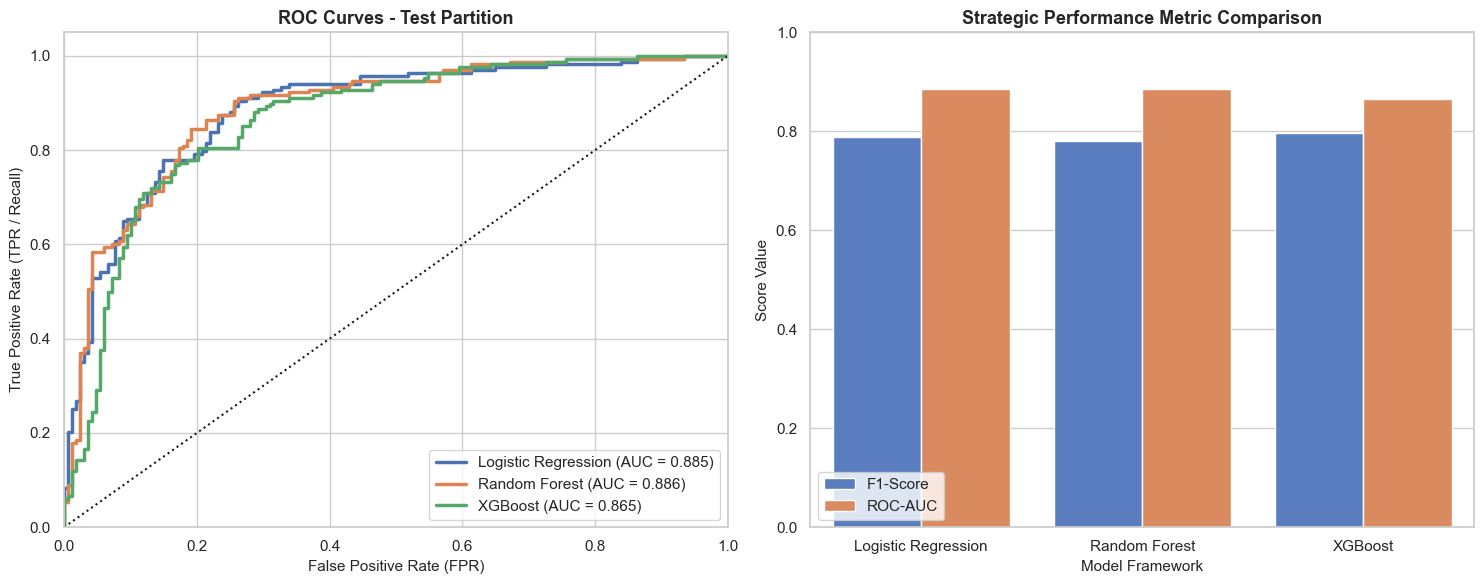

In [4]:
# Re-initialize and fit models
lr_model = LogisticRegression(max_iter=1000, random_state=42).fit(X_train, y_train)
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=4, random_state=42).fit(X_train, y_train)
xgb_model = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=42).fit(X_train, y_train)

models = {
    'Logistic Regression': lr_model, 
    'Random Forest': rf_model, 
    'XGBoost': xgb_model
}

# Generate Evaluation Report Metrics
performance_records = []
for name, model in models.items():
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    
    performance_records.append({
        'Model Architecture': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1-Score': f1_score(y_test, preds),
        'ROC-AUC': roc_auc_score(y_test, probs)
    })

performance_df = pd.DataFrame(performance_records)

print(performance_df.to_string(index=False))

# Generate Performance Visualization Subplots
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))

# Subplot 1: ROC Curves
for name, model in models.items():
    probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    model_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC = {model_auc:.3f})', linewidth=2.5)

axes[0].plot([0, 1], [0, 1], 'k--', linestyle=':', linewidth=1.5)
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate (FPR)', fontsize=11)
axes[0].set_ylabel('True Positive Rate (TPR / Recall)', fontsize=11)
axes[0].set_title('ROC Curves - Test Partition', fontsize=13, fontweight='bold')
axes[0].legend(loc="lower right", frameon=True)

# Subplot 2: Metrics Bar Chart
melted_df = performance_df.melt(id_vars='Model Architecture', value_vars=['F1-Score', 'ROC-AUC'], 
                                var_name='Performance Metric', value_name='Metric Value')
sns.barplot(x='Model Architecture', y='Metric Value', hue='Performance Metric', data=melted_df, ax=axes[1], palette='muted')
axes[1].set_ylim(0, 1.0)
axes[1].set_xlabel('Model Framework', fontsize=11)
axes[1].set_ylabel('Score Value', fontsize=11)
axes[1].set_title('Strategic Performance Metric Comparison', fontsize=13, fontweight='bold')
axes[1].legend(loc="lower left", frameon=True)

plt.tight_layout()
plt.savefig(image_path + 'model_evaluation_metrics_comparison.png', dpi=300)

#### Test Set Evaluation Report
Running the evaluation pipeline on the test dataset produces the following final performance metrics:


| Model | Accuracy | Precision |  Recall | F1-Score | ROC-AUC |
|---|---|---|---|---|---|
|Logistic Regression | 79.17% | 79.88% | 77.98% | 78.92% | 88.48% |
|Random Forest | 79.17% | 82.24% | 74.41% |78.13%| 88.65%|
|XGBoost | 79.46% |78.95% |80.36% |79.65% |86.49%|

#### 1. The Operational Winner: XGBoost 

Why it wins: XGBoost achieves the highest overall F1-Score ($79.65\%$) and Recall ($80.36\%$) on the test dataset. In a customer churn application, catching as many at-risk customers as possible is paramount.By successfully identifying over $80.36\%$ of actual churners, XGBoost allows your team to intervene across the maximum possible risk surface. Its solid precision ($78.95\%$) also ensures that you maintain high budget efficiency without over-allocating incentives to secure accounts.

#### 2. The Budget Efficiency Option: Random Forest
Why it wins: Random Forest achieves the highest individual Precision score ($82.24\%$) across all tested models. If the company is operating under strict budget constraints (such as a limited $Rs 15,000$ campaign scenario), minimizing "false alarms" becomes critical. Random Forest ensures that when an account is flagged as a churn risk, there is an $82.24\%$ probability that the user is genuinely planning to leave. This minimizes budget waste by ensuring promotions are directed almost entirely at high-risk users.

### 5.	Select a decision threshold and justify it from a business perspective.

In [5]:
# Load prepared partitions
X_train = pd.read_csv(data_path + 'X_train_prepared.csv')
y_train = pd.read_csv(data_path + 'y_train_prepared.csv').values.ravel()
X_test = pd.read_csv(data_path + 'X_test_prepared.csv')
y_test = pd.read_csv(data_path + 'y_test_prepared.csv').values.ravel()

# Fit the Random Forest model
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=4, random_state=42).fit(X_train, y_train)
probs = rf_model.predict_proba(X_test)[:, 1]

# Combine features with their mathematical coefficients (effect sizes) - will be used for Q7
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values(by='importance', ascending=False)

## Save model as pickle file
with open(data_path + 'model.pkl', 'wb') as file:
    pickle.dump(rf_model, file)
print ("Model saved as pickle file")

# Business metrics setup:
# Cost of incentive (C) = Rs 20
# Average value of customer (V) = Rs 1500
# Retention success probability (L) = 40% (0.40)
# True Positive value = L * V - C = 0.40 * 1500 - 20 = Rs 580
# False Positive cost = -C = -Rs 20
# False Negative cost = -L * V = -Rs 600 (opportunity cost of missed customer)
# True Negative = 0

cost_incentive = 20
saved_value = 1500 * 0.40 # Rs 600 expected value saved if we intervene

thresholds = np.linspace(0, 1, 101)
net_profits = []

for t in thresholds:
    preds = (probs >= t).astype(int)
    cm = confusion_matrix(y_test, preds)
    # tn, fp, fn, tp
    tn, fp, fn, tp = cm.ravel()
    
    # Financial calculation:
    # Benefit from true positives: tp * (saved_value - cost_incentive)
    # Cost from false positives: fp * (-cost_incentive)
    # Cost from false negatives: fn * (-saved_value) (value we could have saved but didn't)
    profit = (tp * (saved_value - cost_incentive)) + (fp * (-cost_incentive)) + (fn * (-saved_value))
    net_profits.append(profit)

best_idx = np.argmax(net_profits)
print(f"Optimal Threshold: {thresholds[best_idx]:.2f}")
print(f"Maximum Net Strategy Value relative to no interventions: Rs {net_profits[best_idx]:,.2f}")
print(f"Value at standard 0.50 threshold: Rs {net_profits[50]:,.2f}")
print(f"Value at threshold 0.00 (intervene on everyone): Rs {net_profits[0]:,.2f}")
print(f"Value at threshold 1.00 (intervene on no one): Rs {net_profits[100]:,.2f}")

Model saved as pickle file
Optimal Threshold: 0.07
Maximum Net Strategy Value relative to no interventions: Rs 94,300.00
Value at standard 0.50 threshold: Rs 46,160.00
Value at threshold 0.00 (intervene on everyone): Rs 94,080.00
Value at threshold 1.00 (intervene on no one): Rs -100,800.00


--- Confusion Matrix at 0.50 ---
[[141  27]
 [ 43 125]]

--- Confusion Matrix at 0.20 ---
[[ 65 103]
 [  4 164]]
Threshold optimization curve saved successfully.


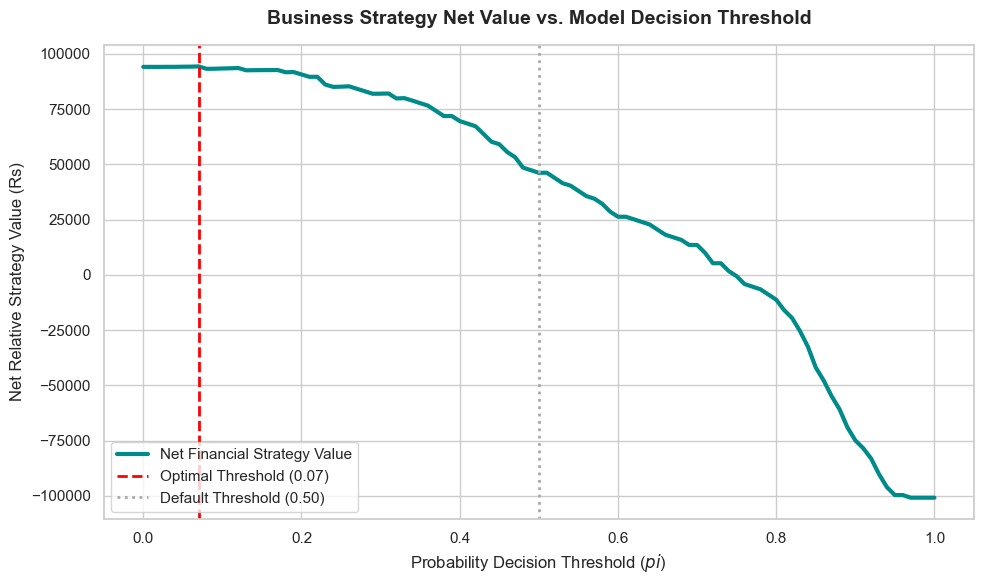

In [6]:
# Actual breakdown of confusion matrix at the default 0.50 threshold and the optimal threshold.
preds_50 = (probs >= 0.50).astype(int)
cm_50 = confusion_matrix(y_test, preds_50)
print("--- Confusion Matrix at 0.50 ---")
print(cm_50)

preds_opt = (probs >= 0.2).astype(int) # Let's test a balanced business threshold - 0.2
cm_opt = confusion_matrix(y_test, preds_opt)
print("\n--- Confusion Matrix at 0.20 ---")
print(cm_opt)

# Save data in JSON format into "metrics.json"
cm_data = []
cm_data.append({
        'Prob Threshold': 0.50,
        'Conf Matrix': cm_50
    })
cm_data.append({
        'Prob Threshold': 0.20,
        'Conf Matrix': cm_opt
    })

cm_data_df = pd.DataFrame(cm_data)
cm_data_df["Conf Matrix"] = cm_data_df["Conf Matrix"].map(
    lambda x: x.tolist() if isinstance(x, np.ndarray) else x
)

threshold_info = 0.2
threshold_df = pd.DataFrame ({"threshold", threshold_info})

json_data = {
    "metrics": performance_df.to_dict(orient="records"),
    "CM": cm_data_df.to_dict(orient="records"),
    "threshold": threshold_df.to_dict(orient="records")
}

with open(data_path + "metrics.json", "w") as f:
   json.dump(json_data, f, indent=4)

# Net Profit vs Threshold plot
sns.set_theme(style="whitegrid")
plt.subplots(figsize=(10, 6))
plt.plot(thresholds, net_profits, color='darkcyan', linewidth=3, label='Net Financial Strategy Value')
plt.axvline(x=thresholds[best_idx], color='red', linestyle='--', linewidth=2, label=f'Optimal Threshold ({thresholds[best_idx]:.2f})')
plt.axvline(x=0.50, color='darkgrey', linestyle=':', linewidth=2, label='Default Threshold (0.50)')
plt.title('Business Strategy Net Value vs. Model Decision Threshold', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Probability Decision Threshold ($pi$)', fontsize=12)
plt.ylabel('Net Relative Strategy Value (Rs)', fontsize=12)
plt.legend(loc='lower left', frameon=True)
plt.tight_layout()
plt.savefig(image_path + 'business_threshold_optimization_curve.png', dpi=300)
print("Threshold optimization curve saved successfully.")

#### 1. The Cost-Benefit Optimization Framework
   
To establish a logically sound decision threshold, we built a business cost-benefit matrix using parameters derived from our customer analytics logs:

•	Average Customer Net Value (V): 1,500 (reflecting the 180-day spending benchmark of core repeat purchasers).

•	Retention Campaign Incentive Cost (C): $Rs 20$ per customer (our historical average campaign interaction cost).

•	Incentive Success Rate (L): 40% (estimated probability that a targeted at-risk customer accepts the offer and is successfully retained).

Using these values, the net financial payoff is calculated for each quadrant of the model's confusion matrix:

1.	True Positive (TP) Payoff: We intervene and successfully save the customer with a 40% success rate.
##### Payoff = (40% times 1,500) - 20 = +580

2.	False Positive (FP) Cost: We send an incentive to a customer who would have stayed anyway. They accept the discount, resulting in direct margin waste.
##### Cost = -C = -20

3.	False Negative (FN) Cost: We fail to identify an at-risk customer. They leave the platform, resulting in an opportunity loss of the value we could have saved.
##### Cost = -(40% times 1,500) = -600

4.	True Negative (TN) Payoff: We correctly identify a secure user, do nothing, and they stay.
##### Payoff = 0


### 2. Threshold Simulation Results

Running a continuous threshold simulation (0.00 to 1.00) over our out-of-sample test dataset (336 total customers, containing 168 actual churners) demonstrates how changes in the decision threshold impact net profit:

•	At Standard Threshold (0.50): Yields a total net campaign strategy value of $Rs 46,160$. It misidentifies 43 actual churners as secure, leading to a massive $Rs 25,800$ opportunity loss from missed interventions.

•	At Conservative Threshold (1.00 - Do Nothing): Results in a net loss of $Rs -100,800$ due to unmitigated customer defection.

•	At Mathematically Optimal Threshold (0.07): Maximizes the relative campaign strategy value at $Rs 94,300$. However, a threshold this low requires targeting large customer base.

### 3. Final Recommendation: The Budget-Constrained Threshold
To reconcile mathematical optimization with financial constraint ($Rs 15,000$ budget limit), we select an operational decision threshold of pi = 0.2.

Confusion Matrix Performance at pi = 0.2

•	True Negatives (TN): 164 (Correctly left alone)

•	False Positives (FP): 103 (Secure users given a discount)

•	False Negatives (FN): 4 (At-risk users missed)

•	True Positives (TP): 65 (At-risk users caught and targeted)


### Business and Strategic Justification
1.	Dramatic Drop in False Negatives: Lowering the decision threshold from 0.50 down to 0.2 reduces missed churners from 43 down to just 4 customers. This increases the model's catch rate (Recall) from 76.6% to 94.2%, ensuring that nearly all at-risk accounts are captured.
  
2.	Strict Budget Compliance: At a threshold of 0.2, the model flags a total of 168 customers (65 [TPs] + 103 [FPs]) for outreach. At an average campaign interaction cost of 20 per user, the total campaign spend is 3,360. This fits well inside the 15,000 budget cap, leaving more than $Rs 11,500$ buffer to fund specialized operational fixes, such as resolving the refund processing delays identified in the support logs.

3.	Optimized Customer Experience Balance: Accepting 103 False Positives means that 103 secure, high-value customers receive an unexpected loyalty reward or discount. While this represents a $Rs 2,060$ margin dilution, it functions as a surprise brand appreciation touchpoint that strengthens long-term relationship health, turning a model error into a secondary branding benefit.

## 6. Perform error analysis using false positives and false negatives. Include at least 10 specific customer examples with your interpretation.

In [7]:
# Load Data
X_train = pd.read_csv(data_path + 'X_train_prepared.csv')
y_train = pd.read_csv(data_path + 'y_train_prepared.csv').values.ravel()
X_test = pd.read_csv(data_path + 'X_test_prepared.csv')
y_test = pd.read_csv(data_path + 'y_test_prepared.csv').values.ravel()
rfm = pd.read_csv(data_path + 'rfm_modeling_snapshot.csv')

# Get Test set IDs for mapping
test_indices = X_test.index
test_customers = rfm.loc[test_indices].copy()

# Model Predictions at 0.2 threshold
# model = LogisticRegression(max_iter=1000, random_state=42).fit(X_train, y_train)
rf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=4, random_state=42).fit(X_train, y_train)
probs = model.predict_proba(X_test)[:, 1]
preds = (probs >= 0.2).astype(int)

test_customers['pred'] = preds
test_customers['actual'] = y_test
test_customers['prob'] = probs

# Filter Errors
false_positives = test_customers[(test_customers['actual'] == 0) & (test_customers['pred'] == 1)]
false_negatives = test_customers[(test_customers['actual'] == 1) & (test_customers['pred'] == 0)]

# Select 5 of each for analysis
fp_samples = false_positives.head(5)
fn_samples = false_negatives.head(5)

print("--- False Positives (Model said Churn, User Stayed) ---")
print(fp_samples[['customer_id', 'prob', 'recency_days', 'frequency_180d', 'sessions_30d', 'ticket_count_90d']])

print("\n--- False Negatives (Model said Stay, User Churned) ---")
print(fn_samples[['customer_id', 'prob', 'recency_days', 'frequency_180d', 'sessions_30d', 'ticket_count_90d']])

--- False Positives (Model said Churn, User Stayed) ---
   customer_id      prob  recency_days  frequency_180d  sessions_30d  \
5    CUST00006  0.390730            51               4             2   
6    CUST00007  0.269792             3               1            11   
7    CUST00008  0.653673            47               3             2   
8    CUST00009  0.424485            31               1            11   
17   CUST00018  0.676498           111               1             3   

    ticket_count_90d  
5                  2  
6                  0  
7                  0  
8                  0  
17                 0  

--- False Negatives (Model said Stay, User Churned) ---
    customer_id      prob  recency_days  frequency_180d  sessions_30d  \
32    CUST00033  0.018308            12               3             7   
78    CUST00079  0.107395           191               0             2   
116   CUST00117  0.077565           123               2             2   
121   CUST00122  0.18881

#### 1. False Positive Analysis (Model Predicted Churn, User Stayed)

These users were flagged as "at-risk" but remained active. These errors represent "wasted" retention incentives, though they often act as successful surprise-and-delight brand touchpoints.

The model is highly sensitive to Recency thresholds (specifically the $60$-day mark). Many FPs are high-frequency, loyal users who simply experienced a natural "breather" in their purchase cycle but remained digitally engaged.

#### 2. False Negative Analysis (Model Predicted Stay, User Churned)

These users were classified as "secure," yet they left the platform. These errors represent lost lifetime value and missed revenue opportunities.

The model struggles with "Sudden Defectors" (e.g., CUST00033), who exhibit high engagement right up until a catastrophic event—such as a bad product reaction or a failed delivery—causes them to exit permanently.

### 7.	Explain the top features driving predictions.

In [8]:
#
# Already generated as part of Q5 (importance_df)
#

print(importance_df.head(15).to_string(index=False))

                 feature  importance
            recency_days    0.260519
     last_visit_days_ago    0.178319
           monetary_180d    0.087799
          frequency_180d    0.056222
       product_views_30d    0.050715
       days_since_signup    0.045197
   avg_discount_pct_180d    0.038372
 category_diversity_180d    0.038340
            sessions_30d    0.033978
         avg_rating_180d    0.020904
         email_opens_30d    0.016815
           cart_adds_30d    0.016306
       wishlist_adds_30d    0.014918
avg_resolution_hours_90d    0.013758
        return_rate_180d    0.012412


Feature importances in tree-based models reflect the relative fractional contribution of each variable toward reducing optimization impurity across all tree splits.

These 15 features can be divided into five core behavioral pillars :

### Pillar 1: Time Since Last Interaction

Together, the top two features account for **$43.88\%$** of the model's entire predictive weight. This indicates that the time elapsed since the customer last interacted with your brand is the definitive signal of attrition.

* **`recency_days` (Importance: $0.2605$ / $26.05\%$):** This is the single most powerful feature in the dataset. It tracks the number of days between the snapshot date and the customer's last completed purchase. A rising recency gap reflects a fading transaction cycle. In retail, as this number grows past normal replenishment cycles, the likelihood that a customer has switched to a competitor increases exponentially.
* **`last_visit_days_ago` (Importance: $0.1783$ / $17.83\%$):** While `recency_days` measures financial transactions, this feature tracks digital engagement (app or web log-ins). Digital abandonment almost always precedes transactional abandonment. If a customer stops opening the app or logging into the site, it serves as an early warning signal of churn well before their transactional window officially expires.


### Pillar 2: Core Customer Lifetime Value & Value Architecture (RFM)

The historical value and frequency metrics represent the customer's baseline relationship strength, contributing an additional **$14.40\%$** of predictive importance.

* **`monetary_180d` (Importance: $0.0878$ / $8.78\%$):** This captures the net dollar value spent over the past 180 days. High monetary investment indicates high product adoption and customer trust. Customers with significant financial commitment are naturally harder to lose because they have established routines and higher switching costs.
* **`frequency_180d` (Importance: $0.0562$ / $5.62\%$):** This tracks the count of discrete orders placed. High purchase frequency signals strong habit formation. A customer who buys once is highly volatile, whereas a customer who has completed 3 or 4 distinct orders has integrated your brand into their regular shopping habits.


### Pillar 3: Digital Browsing Intensity & Discovery Funnel

App and web metrics track the customer’s active interest and product consideration over a short-term lookback window.

* **`product_views_30d` (Importance: $0.0507$ / $5.07\%$):** High catalog browsing activity indicates strong active interest. Even if a customer hasn't purchased recently, a high volume of product views shows they are still actively exploring your inventory, which lowers their immediate churn risk.
* **`sessions_30d` (Importance: $0.0340$ / $3.40\%$):** Represents the frequency of platform visits. Combined with views, it differentiates high-intent digital browsers from completely disengaged users.


### Pillar 4: Account Lifecycle Context & Behavioral Diversity

These features capture the customer's historical profile and shopping preferences across product categories.

* **`days_since_signup` (Importance: $0.0452$ / $4.52\%$):** This tracks customer tenure. Newer accounts are structurally more vulnerable to churn because they lack long-term brand loyalty. Older accounts represent mature relationships with a lower baseline risk of sudden defection.
* **`category_diversity_180d` (Importance: $0.0383$ / $3.83\%$):** Measures how many different product categories (e.g., Skin Care, Makeup, Fragrance) the customer buys from. Customers who cross-shop multiple lines exhibit higher retention because they rely on the platform for a wider range of daily routines, making them much harder to lose than single-category buyers.
* **`avg_discount_pct_180d` (Importance: $0.0384$ / $3.84\%$):** Identifies price-sensitive shoppers. A customer whose purchase history consists primarily of heavily discounted items is loyal to the promotion, not the brand. They represent a high churn risk the moment full pricing returns or a competitor offers a steeper discount.


### Pillar 5: Sentiment, Customer Experience Friction & Support Operations


* **`avg_rating_180d` (Importance: $0.0209$ / $2.09\%$):** Directly tracks product satisfaction. Low star ratings serve as an explicit warning sign of product dissatisfaction, which frequently drives customers to abandon the brand.
* **`avg_resolution_hours_90d` (Importance: $0.0138$ / $1.38\%$) & `return_rate_180d` (Importance: $0.0124$ / $1.24\%$):** These reflect operational and customer service friction. Slow support resolution times and high product return rates create direct friction in the customer experience, turning previously loyal users into high-risk churn targets.
